# Scraping & EDA: US Colleges and Universities

**Dataset**: List of colleges and universities across 33 US states (Wikipedia).
**Source**: https://en.wikipedia.org/wiki/List_of_colleges_and_universities_in_{STATE}
**Target**: ≥ 5 columns, ≥ 1500 rows (tabular).

In [2]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Scraping Dataset
We use `requests` + `BeautifulSoup`. Helper functions:
- `bersihkan_teks`: removes wiki citations `[1]`, `[note 3]`, extra spaces.
- `angka_atau_none`: extracts an integer from a text cell.
- `bersihkan_control`: normalizes "Public"/"Private" from longer strings.
- `cari_kolom`: finds index of a column by keyword.

In [3]:
HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; AcademicScraper/1.0)"}

def bersihkan_teks(teks):
    if teks is None:
        return None
    teks = re.sub(r"\[[^\]]*\]", "", str(teks))   # remove [1], [note 3]
    teks = " ".join(teks.split()).strip()
    return teks if teks else None

def angka_atau_none(teks):
    if teks is None:
        return None
    if isinstance(teks, (int, float)) and not isinstance(teks, bool):
        return int(teks)
    teks = str(teks).replace(",", "").strip()
    m = re.search(r"\d+", teks)
    return int(m.group()) if m else None

def bersihkan_control(teks):
    if teks is None:
        return None
    t = teks.lower()
    if "public" in t:
        return "Public"
    if "private" in t:
        return "Private"
    return bersihkan_teks(teks)

def cari_kolom_pertama(headers_lower, prefixes):
    for i, h in enumerate(headers_lower):
        for p in prefixes:
            if h.startswith(p):
                return i
    return None

In [4]:
def scrape_state(state):
    """
    Scrape 'List of colleges and universities in {state}' from Wikipedia.
    Returns a list of dicts (School, Location, Control, Type, Enrollment, Founded, State).
    """
    url = f"https://en.wikipedia.org/wiki/List_of_colleges_and_universities_in_{state}"
    r = requests.get(url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "html.parser")

    state_display = state.replace("_", " ")
    tables = soup.find_all("table")
    rows_out = []
    seen = set()

    for table in tables:
        rows = table.find_all("tr")
        if len(rows) < 2:
            continue

        header_cells = rows[0].find_all(["th", "td"])
        headers = [bersihkan_teks(c.get_text(" ", strip=True)) or "" for c in header_cells]
        headers_lower = [h.lower() for h in headers]
        joined = " ".join(headers_lower)

        # Must contain school/institution AND enrollment
        has_school = any(k in joined for k in ["school", "institution", "name"])
        has_enroll = "enrollment" in joined
        if not (has_school and has_enroll):
            continue

        idx_school   = cari_kolom_pertama(headers_lower, ["school", "institution", "name"])
        idx_location = cari_kolom_pertama(headers_lower, ["location"])
        idx_control  = cari_kolom_pertama(headers_lower, ["control"])
        idx_type     = cari_kolom_pertama(headers_lower, ["type", "classification", "carnegie"])
        idx_ug       = cari_kolom_pertama(headers_lower, ["undergraduate enrollment"])
        idx_grad     = cari_kolom_pertama(headers_lower, ["graduate enrollment"])
        idx_enroll   = cari_kolom_pertama(headers_lower, ["enrollment"])   # only single-col pages
        idx_founded  = cari_kolom_pertama(headers_lower, ["founded", "foundation"])

        # If Control column missing → infer from preceding heading (Illinois, Pennsylvania)
        control_from_heading = None
        if idx_control is None:
            prev = table.find_previous(["h2", "h3", "h4"])
            if prev:
                ht = prev.get_text(" ", strip=True).lower()
                if "public" in ht:
                    control_from_heading = "Public"
                elif "private" in ht:
                    control_from_heading = "Private"

        for row in rows[1:]:
            cells = row.find_all(["th", "td"])
            if not cells:
                continue
            data = [bersihkan_teks(c.get_text(" ", strip=True)) for c in cells]

            if idx_school is None or idx_school >= len(data):
                continue
            school = data[idx_school]
            if not school or school.lower() in ("school", "institution", "name"):
                continue
            if len(data) < 3:           # skip section headers / stray rows
                continue

            location = data[idx_location] if (idx_location is not None and idx_location < len(data)) else None

            if idx_control is not None and idx_control < len(data):
                control = bersihkan_control(data[idx_control])
            else:
                control = control_from_heading

            type_val = data[idx_type] if (idx_type is not None and idx_type < len(data)) else None

            # Enrollment
            enrollment = None
            if idx_ug is not None and idx_grad is not None:
                ug = angka_atau_none(data[idx_ug]) if idx_ug < len(data) else None
                gr = angka_atau_none(data[idx_grad]) if idx_grad < len(data) else None
                if ug is not None or gr is not None:
                    enrollment = (ug or 0) + (gr or 0)
            elif idx_enroll is not None and idx_enroll < len(data):
                enrollment = angka_atau_none(data[idx_enroll])

            founded = angka_atau_none(data[idx_founded]) if (idx_founded is not None and idx_founded < len(data)) else None

            key = (school.lower(), state_display)
            if key in seen:
                continue
            seen.add(key)

            rows_out.append({
                "School":     school,
                "Location":   location,
                "Control":    control,
                "Type":       type_val,
                "Enrollment": enrollment,
                "Founded":    founded,
                "State":      state_display,
            })

    return rows_out

In [5]:
STATES = [
    "Michigan", "Ohio", "North_Carolina", "Massachusetts", "Virginia",
    "Indiana", "Missouri", "Tennessee", "Minnesota", "Wisconsin",
    "Pennsylvania", "Illinois", "North_Dakota", "Utah", "Iowa",
    "Connecticut", "Maine", "New_Hampshire", "Rhode_Island", "Vermont",
    "Alabama", "Arkansas", "Arizona", "Hawaii", "Idaho",
    "New_Mexico", "Wyoming", "South_Dakota", "Mississippi", "Oklahoma",
    "South_Carolina", "West_Virginia", "New_Jersey",
]

all_rows = []
for s in STATES:
    try:
        rows = scrape_state(s)
        print(f"{s:<16} -> {len(rows):>4} rows")
        all_rows.extend(rows)
    except Exception as e:
        print(f"{s:<16} -> ERROR: {e}")
    time.sleep(1)  # be polite to Wikipedia

print("\nTotal rows:", len(all_rows))
df_raw = pd.DataFrame(all_rows)
df_raw.to_csv("colleges_raw.csv", index=False)
print("Saved to colleges_raw.csv  shape:", df_raw.shape)

Michigan         ->   83 rows
Ohio             ->  100 rows
North_Carolina   ->   64 rows
Massachusetts    ->   97 rows
Virginia         ->  119 rows
Indiana          ->   65 rows
Missouri         ->   39 rows
Tennessee        ->   53 rows
Minnesota        ->   76 rows
Wisconsin        ->   60 rows
Pennsylvania     ->  188 rows
Illinois         ->   97 rows
North_Dakota     ->   20 rows
Utah             ->   21 rows
Iowa             ->   52 rows
Connecticut      ->   25 rows
Maine            ->   29 rows
New_Hampshire    ->   24 rows
Rhode_Island     ->   13 rows
Vermont          ->   12 rows
Alabama          ->   60 rows
Arkansas         ->   49 rows
Arizona          ->   35 rows
Hawaii           ->   15 rows
Idaho            ->   14 rows
New_Mexico       ->   26 rows
Wyoming          ->   12 rows
South_Dakota     ->   21 rows
Mississippi      ->   33 rows
Oklahoma         ->   31 rows
South_Carolina   ->   56 rows
West_Virginia    ->   36 rows
New_Jersey       ->   57 rows

Total row

## 2. Import dan Pemahaman Dataset

In [6]:
df = pd.read_csv("colleges_raw.csv")
print("Shape:", df.shape)
df.head()

Shape: (1682, 7)


,School,Location,Control,Type,Enrollment,Founded,State
0,Central Michigan University,Mount Pleasant,Public,Doctoral university with high research activit...,14488.0,1892.0,Michigan
1,Eastern Michigan University,Ypsilanti,Public,Doctoral university with high research activit...,12631.0,1849.0,Michigan
2,Michigan State University,East Lansing,Public,Doctoral university with very high research ac...,52089.0,1855.0,Michigan
3,Michigan Technological University,Houghton,Public,Doctoral university with very high research ac...,7403.0,1885.0,Michigan
4,Oakland University,Rochester Hills,Public,Doctoral university with high research activit...,15768.0,1957.0,Michigan


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   School      1682 non-null   object 
 1   Location    1664 non-null   object 
 2   Control     1534 non-null   object 
 3   Type        1645 non-null   object 
 4   Enrollment  1634 non-null   float64
 5   Founded     1463 non-null   float64
 6   State       1682 non-null   object 
dtypes: float64(2), object(5)
memory usage: 92.1+ KB


In [8]:
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nUnique states:", df["State"].nunique())
print(df["State"].value_counts())

Shape: (1682, 7)

Dtypes:
School         object
Location       object
Control        object
Type           object
Enrollment    float64
Founded       float64
State          object
dtype: object

Missing values:
School          0
Location       18
Control       148
Type           37
Enrollment     48
Founded       219
State           0
dtype: int64

Unique states: 33
State
Pennsylvania      188
Virginia          119
Ohio              100
Illinois           97
Massachusetts      97
Michigan           83
Minnesota          76
Indiana            65
North Carolina     64
Wisconsin          60
Alabama            60
New Jersey         57
South Carolina     56
Tennessee          53
Iowa               52
Arkansas           49
Missouri           39
West Virginia      36
Arizona            35
Mississippi        33
Oklahoma           31
Maine              29
New Mexico         26
Connecticut        25
New Hampshire      24
South Dakota       21
Utah               21
North Dakota       20
Hawaii   

In [9]:
attribute_types = pd.DataFrame({
    "Column":     ["School", "Location", "Control", "Type", "Enrollment", "Founded", "State"],
    "Data Type":  ["object", "object", "object", "object", "int/float", "int/float", "object"],
    "Attribute":  ["Nominal", "Nominal", "Nominal (binary)", "Nominal",
                   "Numeric (discrete)", "Numeric (discrete)", "Nominal"],
    "Notes": [
        "Unique name of institution",
        "City / metro area",
        "Public vs Private",
        "Carnegie classification / institution type",
        "Total student headcount",
        "Year of founding",
        "US state",
    ]
})
attribute_types

,Column,Data Type,Attribute,Notes
0,School,object,Nominal,Unique name of institution
1,Location,object,Nominal,City / metro area
2,Control,object,Nominal (binary),Public vs Private
3,Type,object,Nominal,Carnegie classification / institution type
4,Enrollment,int/float,Numeric (discrete),Total student headcount
5,Founded,int/float,Numeric (discrete),Year of founding
6,State,object,Nominal,US state


## 3. Analisis Statistik dan Kualitas Data

In [10]:
numeric_cols = ["Enrollment", "Founded"]

desc = pd.DataFrame({
    "mean":   df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
    "mode":   df[numeric_cols].mode().iloc[0],
    "std":    df[numeric_cols].std(),
    "min":    df[numeric_cols].min(),
    "max":    df[numeric_cols].max(),
    "q1":     df[numeric_cols].quantile(0.25),
    "q3":     df[numeric_cols].quantile(0.75),
}).round(2)
desc

,mean,median,mode,std,min,max,q1,q3
Enrollment,5593.43,2147.5,200.0,12516.81,6.0,210208.0,870.25,5188.75
Founded,1920.12,1920.0,1966.0,53.55,1636.0,2024.0,1881.00,1966.00


In [11]:
for col in ["Control", "State"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Control ---
Control
Private                                                                     808
Public                                                                      592
NaN                                                                         148
Pennsylvania State University Commonwealth Campuses                          20
PASSHE                                                                       14
Proprietary (for-profit)                                                     12
Commonwealth System of Higher Education                                       8
Community                                                                     8
Presbyterian Church (USA)                                                     7
Evangelical Lutheran Church in America                                        5
Catholic Church ( Sisters of Mercy )                                          4
United Methodist Church                                                       4
Catholic Church

In [12]:
# Top 10 most common 'Type' values
print("\nTop 10 Type values:")
print(df["Type"].value_counts().head(10))


Top 10 Type values:
Type
Associate's college          217
Baccalaureate college        198
Master's university          155
Special-focus institution    105
Research university           73
Masters university            37
Master's                      36
Baccalaureate                 35
Doctoral university           23
Public                        23
Name: count, dtype: int64


In [13]:
missing = df.isnull().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing

,missing_count,missing_pct
School,0,0.00
Location,18,1.07
Control,148,8.80
Type,37,2.20
Enrollment,48,2.85
Founded,219,13.02
State,0,0.00


In [14]:
# Strategy:
# - Drop rows without School (shouldn't happen).
# - Location: fill with "Unknown".
# - Control: fill with "Unknown" (rare).
# - Enrollment: fill with median (robust to outliers).
# - Founded: fill with median.
# - Type: fill with "Unknown".

df = df.dropna(subset=["School"]).copy()

df["Location"] = df["Location"].fillna("Unknown")
df["Control"]  = df["Control"].fillna("Unknown")
df["Type"]     = df["Type"].fillna("Unknown")

df["Enrollment"] = df["Enrollment"].fillna(df["Enrollment"].median())
df["Founded"]    = df["Founded"].fillna(df["Founded"].median())

# Cast to int since they're discrete counts/years
df["Enrollment"] = df["Enrollment"].astype(int)
df["Founded"]    = df["Founded"].astype(int)

print("Missing after cleaning:")
print(df.isnull().sum())
print("\nFinal shape:", df.shape)

Missing after cleaning:
School        0
Location      0
Control       0
Type          0
Enrollment    0
Founded       0
State         0
dtype: int64

Final shape: (1682, 7)


In [15]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

for col in ["Enrollment", "Founded"]:
    mask, lo, hi = iqr_outliers(df[col])
    print(f"\n{col}: Q1-IQR bounds = [{lo:.0f}, {hi:.0f}]")
    print(f"  Outliers: {mask.sum()} ({mask.mean()*100:.2f}%)")
    print(f"  Min/Max: {df[col].min()} / {df[col].max()}")


Enrollment: Q1-IQR bounds = [-5293, 11202]
  Outliers: 192 (11.41%)
  Min/Max: 6 / 210208

Founded: Q1-IQR bounds = [1768, 2084]
  Outliers: 7 (0.42%)
  Min/Max: 1636 / 2024


## 4. Visualisasi Data

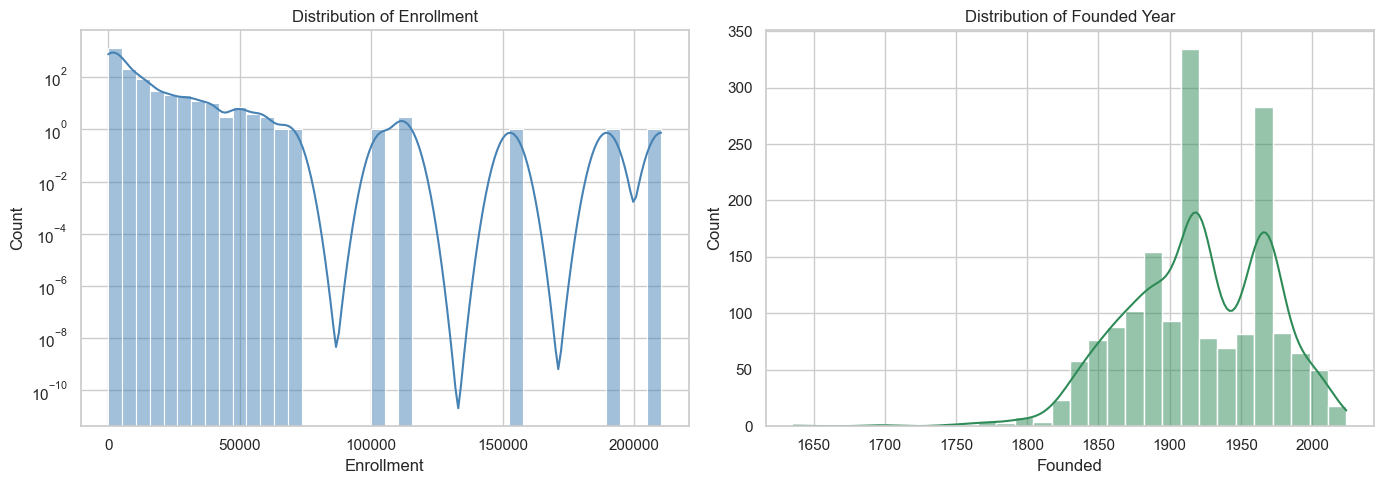

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Enrollment"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Enrollment")
axes[0].set_xlabel("Enrollment")
axes[0].set_yscale("log")     # heavy right skew, log helps

sns.histplot(df["Founded"], bins=30, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Distribution of Founded Year")
axes[1].set_xlabel("Founded")

plt.tight_layout()
plt.show()

In [17]:
# The Wikipedia tables are inconsistent across states:
#  - Michigan/Ohio/... put "Public" / "Private not-for-profit" / "Private" in Control
#  - Pennsylvania puts religious affiliation (e.g. "Catholic Church (Franciscans)")
#  - Illinois sometimes puts "Nonsectarian", "PASSHE", system names, etc.
# We collapse everything to just Public / Private / Other (Unknown bucket).

def classify_control(val):
    if val is None:
        return "Unknown"
    s = str(val).strip().lower()

    # Explicit Public markers
    if ("public" in s
            or "state university system" in s
            or "commonwealth system" in s
            or "passhe" in s
            or s.startswith("suny")
            or s.startswith("cuny")):
        return "Public"

    # Explicit Private markers
    if ("private" in s
            or "not-for-profit" in s
            or "for-profit" in s
            or "proprietary" in s):
        return "Private"

    # Religious / sectarian affiliations are almost always private institutions
    religious_keywords = [
        "church", "catholic", "baptist", "methodist", "lutheran",
        "presbyterian", "jewish", "christian", "nondenominational",
        "nonsectarian", "disciples", "moravian", "reformed",
        "evangelical", "sisters", "franciscans", "jesuit",
        "adventist", "pentecostal", "mormon", "lds",
        "assemblies of god", "church of god", "brethren",
    ]
    if any(k in s for k in religious_keywords):
        return "Private"

    return "Other"

df["Control"] = df["Control"].apply(classify_control)

print("Control distribution after normalization:")
print(df["Control"].value_counts())

Control distribution after normalization:
Control
Private    884
Public     614
Other      184
Name: count, dtype: int64


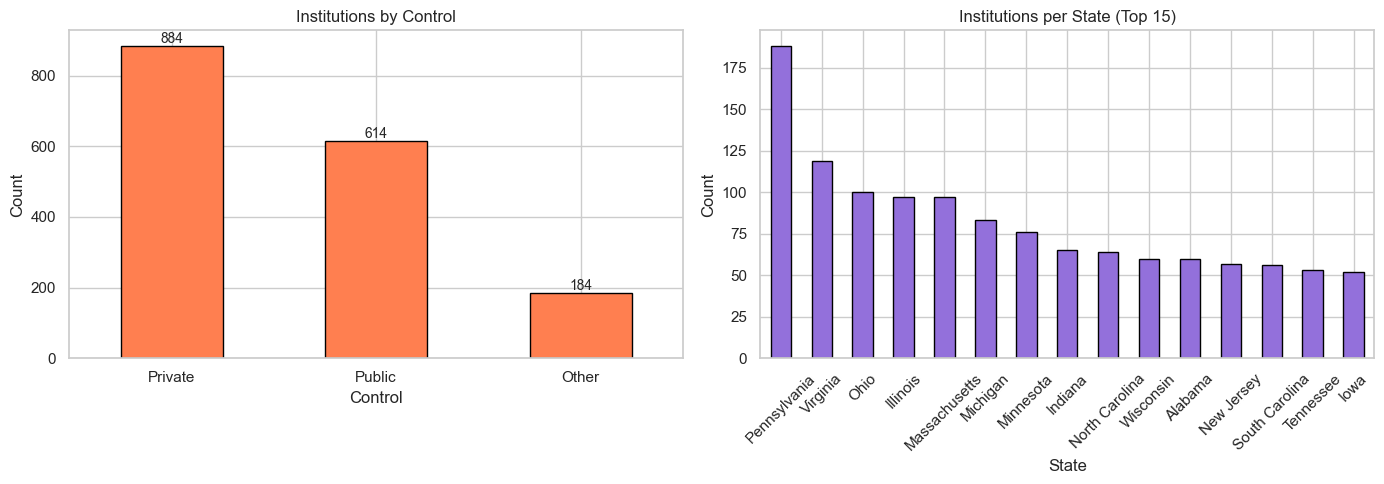

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Control"].value_counts().plot(kind="bar", ax=axes[0], color="coral", edgecolor="black")
axes[0].set_title("Institutions by Control")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=10)

top_states = df["State"].value_counts().head(15)
top_states.plot(kind="bar", ax=axes[1], color="mediumpurple", edgecolor="black")
axes[1].set_title("Institutions per State (Top 15)")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

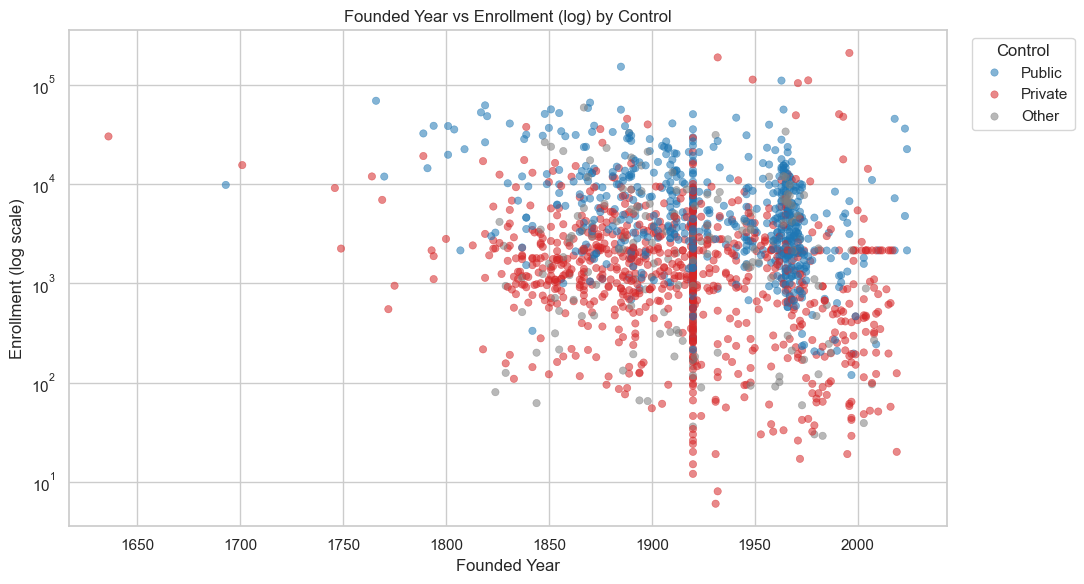

In [24]:
plt.figure(figsize=(11, 6))
palette = {"Public": "#1f77b4", "Private": "#d62728",
           "Other": "#7f7f7f", "Unknown": "#cccccc"}

sns.scatterplot(data=df, x="Founded", y="Enrollment",
                hue="Control", palette=palette, alpha=0.55, s=28,
                edgecolor=None)
plt.yscale("log")
plt.title("Founded Year vs Enrollment (log) by Control")
plt.xlabel("Founded Year")
plt.ylabel("Enrollment (log scale)")
plt.legend(title="Control", bbox_to_anchor=(1.02, 1), loc="upper left",
           frameon=True)
plt.tight_layout()
plt.show()

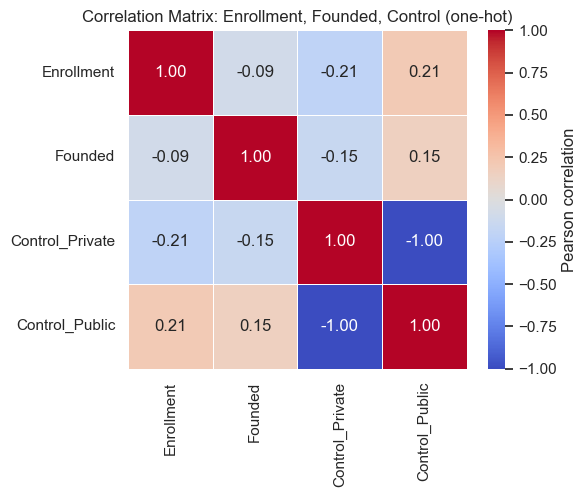

In [29]:
# Work on the two main groups only
df_ctrl = df[df["Control"].isin(["Public", "Private"])].copy()

# Encode Control as a binary numeric column
df_ctrl["Control_bin"] = (df_ctrl["Control"] == "Public").astype(int)

# One-hot encode Control
dummies = pd.get_dummies(df_ctrl["Control"], prefix="Control")

# Attach the numeric columns
mat = pd.concat([df_ctrl[["Enrollment", "Founded"]], dummies], axis=1)

# Correlation matrix
corr = mat.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Correlation Matrix: Enrollment, Founded, Control (one-hot)")
plt.tight_layout()
plt.show()

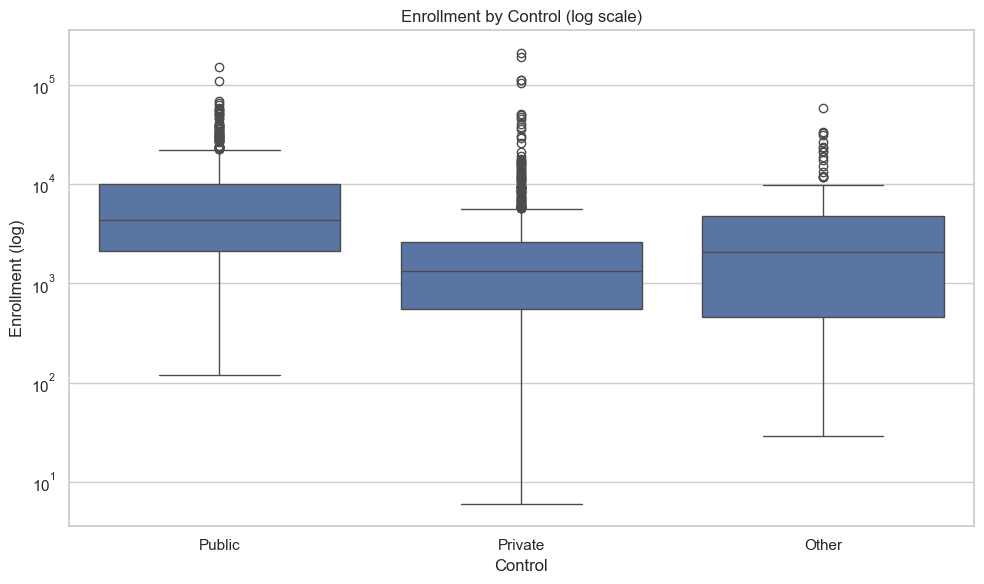

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Control", y="Enrollment", showfliers=True)
plt.yscale("log")
plt.title("Enrollment by Control (log scale)")
plt.xlabel("Control")
plt.ylabel("Enrollment (log)")
plt.tight_layout()
plt.show()

In [22]:
df.to_csv("colleges_clean.csv", index=False)
print("Cleaned dataset saved. Shape:", df.shape)

Cleaned dataset saved. Shape: (1682, 7)
